# Alignment problem experiment:
### <u>Problem setup </u>:

 Given two 3D point clouds $X$ and $Y$ where $Y = RX + \sigma N$ for an unknown rotation $R \in SO(3)$ and additive gaussian noise $N \sim \mathcal{N}(0,1)$ with variance $\sigma$, our goal is estimating the unknown underlying rotation $R$.

 ### <u>Experiment description</u>:
 We compare SOTA ICP method for shape matching, global unconstrained Optimal Transport (OT) matching approach and our method, all with repsect to the relative error $\|R - R_{est}\|_2$, between the estimate rotation and the ground truth for varying values of $\sigma$.

### <u>The steps of our method </u>:
#### Step 1: Apply $\text{RSC}$ on $X$ and $Y$
#### Step 2: Match between the k centroids of the k clusters of $X$ and $Y$ obtained by the $\text{RSC}$
#### Step 3: Simultaneously solve k smaller unconstrained OT matchings between every two matches clusters of $X$ and $Y$
#### Step 4: Concatinate the correspondence between every pair of clusters of $X$ and $Y$ into a global, block structured correspondence between $X$ and $Y$.

In [18]:
import sys
from pathlib import Path
sys.path.append('../')

from matching_clustering.utils import LapOT
from matching_clustering.helpers_3D import create_3D_clouds, plot_3D_point_clouds_side_by_side, plot_point_clouds_only, spectral_cluster_labels
from matching_clustering.precompute_helpers import cost_matrix_c, build_cluster_matrix
from __future__ import annotations
import numpy as np
from sklearn.cluster import SpectralClustering
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csgraph
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

## Set cloud $Y$ to be rotated version of cloud  $X$ to which we add Gaussian noise


In [19]:
%load_ext autoreload
%autoreload 2

def make_rot_xy(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0.0],
                     [s,  c, 0.0],
                     [0.0, 0.0, 1.0]])

def rotate_and_noisify(X, angle=np.pi - 2, noise_std=0.009, seed=None):
    """
    X: np.ndarray of shape (N, 3)
    angle: rotation (radians) in the x-y plane
    noise_std: stddev of isotropic Gaussian noise added to each coord
    seed: optional int for reproducibility
    """
    R = make_rot_xy(angle)
    Y = X @ R.T
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
    Y_noisy = Y + rng.normal(0.0, noise_std, size=Y.shape)
    noise = Y_noisy - Y

    signal_power = np.mean(np.sum(Y**2, axis=1))
    noise_power  = np.mean(np.sum(noise**2, axis=1))

    snr_db = 10 * np.log10(signal_power / noise_power)

    return Y_noisy, snr_db

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Visualize both clouds $X$ and $Y$ (plotting $Y$ without the rotation, so it will be seen from the same angle as $X$)

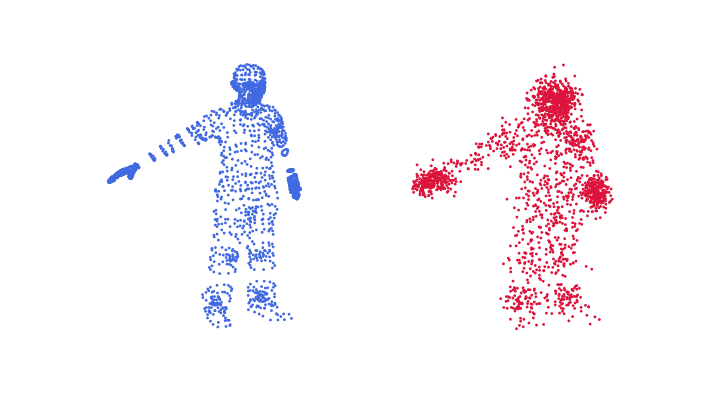

In [ ]:
path_X = "../Data/CAPOD/class1/m1.obj"
X, _ = create_3D_clouds(path_X, path_X)

Y_for_plot, _ = rotate_and_noisify(X, angle=0, noise_std=0.04, seed=42) # Just for purposes of  viewing X and Y from the same angle

Y, _ = rotate_and_noisify(X, angle=np.pi/2, noise_std=0.04, seed=42)  
# plot_3D_point_clouds_side_by_side(X, Y, title="Rotated + Noisy Y vs Original X")

n, m = X.shape[0], Y.shape[0]

labels__X, labels__Y = np.zeros(n), np.zeros(m)

# prepare the output path for the figure if we want to save it,
# set save_path in the function call below to output_path to save the figure
base_dir = Path.cwd()  
output_path = base_dir / "Figures" / "Alignment" /"Alignment_data_04_noise.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)



plot_point_clouds_only(
    X,
    Y_for_plot,
    labels__X,
    labels__Y,
    elev_X=15,
    azim_X=250,
    roll_X=0,
    elev_Y=15,
    azim_Y=250,
    roll_Y=0,
    zoom_X=1.4,
    zoom_Y=1.4,
    wspace=-0.34, 
    point_size=1,
    alpha=1.0,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=True
)

### Pre-compute $C, L_X, L_Y$ and the marginals $a$ and $b$

In [22]:
# Calculate the Gaussian (RBF) kernel matrices for X and Y
W_X = rbf_kernel(X, gamma=1/(0.25*2))
W_Y = rbf_kernel(Y, gamma=1/(0.25*2))


# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


# can we do nearest neighbor graph
# adjust sigma values for smaller significatnce neighborhoodd

W_X_match = rbf_kernel(X, gamma=1/(0.077**2*2))
np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(0.077**2*2))
np.fill_diagonal(W_Y_match, 0)


# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()


In [23]:
L_X_match = csgraph.laplacian(W_X_match, normed=False)
L_Y_match = csgraph.laplacian(W_Y_match, normed=False)

L_X_match_normed = csgraph.laplacian(W_X_match, normed=True)
L_Y_match_normed = csgraph.laplacian(W_Y_match, normed=True)

In [10]:
C = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 1048 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 53784 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 143384 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 258584 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done 399384 tasks      | elapsed:   30.8s
[Parallel(n_jobs=-1)]: Done 565784 tasks      | elapsed:   41.7s
[Parallel(n_jobs=-1)]: Done 757784 tasks      | elapsed:   54.3s
[Parallel(n_jobs=-1)]: Done 975384 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1218584 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1487384 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1781784 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 2101784 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 2447384 tasks      | elapsed:  2.7min
[Parallel(n_jo

### Solve $\text{LapOT}$ and refine $L_X, L_Y$ based on the switch matrices $\pi_{switch}^X$ and $\pi_{switch}^Y$

In [24]:
epsilon = 1e-6
l = 0.1  # lambda
l_x = 10 #10
l_y = 10 #10

# optimize our objective
prob = LapOT(L_X_match, L_Y_match, C, l, l_x, l_y, w=a, v=b)
pi_fp = prob.solve(method='fp',tau_scale=1, max_iter=1000, verbose=True)


# derive the switch matrices
pi_switch_x = build_cluster_matrix(pi_fp, k=3)
pi_switch_y = build_cluster_matrix(pi_fp.T, k=3)

# refine the similarity matrices
new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

SC_X = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_X = SC_X.fit_predict(new_similarity_x)

SC_Y = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_Y = SC_Y.fit_predict(new_similarity_y)

Initialization: objective = -1.374972459781404
Implement fixed point algorithm
max of entropy term :-1.5227141918400884 
 max of main term: 0.10272964135571709
Iteration 1: objective = -1.4199845504843713, objective relative change = -0.03273672165777308, pi change (L1) = 0.6849442374034509
max of entropy term :-1.522931075614878 
 max of main term: 0.10294254587348156
Iteration 2: objective = -1.4199885297413963, objective relative change = -2.802324168697693e-06, pi change (L1) = 0.006661361779931555
max of entropy term :-1.5229210531884416 
 max of main term: 0.10293248253711033
Iteration 3: objective = -1.4199885706513313, objective relative change = -2.8810046094260102e-08, pi change (L1) = 0.0005325745795882078
max of entropy term :-1.5229219717459057 
 max of main term: 0.10293340006580216
Iteration 4: objective = -1.4199885716801035, objective relative change = -7.244932810166645e-10, pi change (L1) = 6.810840429953521e-05
max of entropy term :-1.5229218579542043 
 max of main 

### Visualize results of $\text{RSC}$ applied on clouds $X$ and $Y$

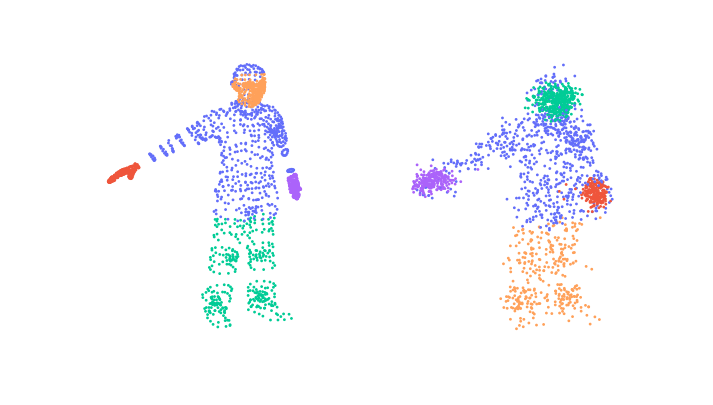

In [ ]:
# prepare the output path for the figure if we want to save it,
# set save_path in the function call below to output_path to save the figure
base_dir = Path.cwd()  
output_path = base_dir / "Figures" /"Alignment" /  "RSC_alignment_04_noise.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plot_point_clouds_only(
    X,
    Y_for_plot,
    labels_refined_X,
    labels_refined_Y,
    elev_X=15,
    azim_X=250,
    roll_X=0,
    elev_Y=15,
    azim_Y=250,
    roll_Y=0,
    zoom_X=1.4,
    zoom_Y=1.4,
    wspace=-0.34, 
    point_size=1,
    alpha=1.0,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=False
)

### Partition $X$ and $Y$ into their clusters based on the labels we got from the $\text{RSC}$ step above
#### Compute centroids of each cluster (based on cluster median or mean)


In [28]:
clusters_X = [X[labels_refined_X == i] for i in range(5)]
clusters_Y = [Y[labels_refined_Y == i] for i in range(5)]

centroids_X = [np.median(cluster, axis=0) for cluster in clusters_X] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
centroids_Y = [np.median(cluster, axis=0) for cluster in clusters_Y] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
a_clusters =np.hstack([a[labels_refined_X == i].sum() / np.sum(a) for i in range(5)])
b_clusters = np.hstack([b[labels_refined_Y == i].sum() / np.sum(b) for i in range(5)])


# Calculate the full distance matrix
pairwise_distances_centroids_X = pairwise_distances(np.vstack(centroids_X), metric='euclidean')
pairwise_distances_centroids_Y = pairwise_distances(np.vstack(centroids_Y), metric='euclidean')


C_centroids = cost_matrix_c(pairwise_distances_centroids_X, pairwise_distances_centroids_Y, a=a_clusters, b=b_clusters)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished


### Match between cluster centroids of $X$ and $Y$

In [29]:
import ot


N = C_centroids.shape[0]

a_unif = np.ones(N) / N
b_unif = np.ones(N) / N

# Exact OT plan
gamma = ot.emd(a_unif, b_unif, C_centroids)
j_max = np.argmax(gamma, axis=1)


print("Cluster correspondences:",'[0 1 2 3 4] of X to -->', j_max, 'of Y')

Cluster correspondences: [0 1 2 3 4] of X to --> [0 1 2 3 4] of Y


## Calculate 5 simultaneous matches (Cluster to cluster)
### Step 1: Pre-compute cost matrices $C_1, \dots, C_5$

In [30]:
pairwise_X = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_X]
pairwise_Y = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_Y]
a_clusters = [a[labels_refined_X == i] / np.sum(a[labels_refined_X == i]) for i in range(5)]
b_clusters = [b[labels_refined_Y == i] / np.sum(b[labels_refined_Y == i]) for i in range(5)]
C_clusters = [cost_matrix_c(pairwise_X[i], pairwise_Y[j_max[i]], a=a_clusters[i], b=b_clusters[j_max[i]]) for i in range(5)]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 434277 out of 434277 | elapsed:   12.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 66286 out of 66286 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 118335 out of 118335 | elapsed:    2.5s finished
[Parallel(n_jobs=-1)]: Using backen

### Step 2: Match between the clusters of $X$ and their assigned clusters in $Y$ based on the above computed cost matrices

In [31]:
a_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_X]
b_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_Y]

gamma_clusters = [ot.emd(a_unifs[i], b_unifs[j_max[i]], C_clusters[i]) for i in range(5)]

### $\bullet$ Set the correspondence between every point $x_i \in X$ to be the maximal entry of it's match with $Y$
### $\bullet$ Calculate the global OT plan between $X$ and $Y$ given the pre-computed cost matrix $C$

In [33]:
J_max = [np.argmax(gamma_clusters[i], axis=1) for i in range(5)]
Y_new = [clusters_Y[j_max[i]][J_max[i]] for i in range(5)]

# Arrange the the data according to the new correspondences
Y__new = np.vstack(Y_new)
X__new = np.vstack(clusters_X)


# Calculate global correspondence using the original cost matrix C and unconstrained OT
global_a_unif, global_b_unif = np.ones(X.shape[0]) / X.shape[0], np.ones(Y.shape[0]) / Y.shape[0]
PI = ot.emd(global_a_unif, global_b_unif, C)
arg_max_PI = np.argmax(PI, axis=1)
reordered_Y = Y[arg_max_PI]

### Estimate the underlying rotation using Procrustes algorithm

In [34]:
def estimate_rotation(cloud_1, cloud_2):

  # X, Y: (n,3) arrays with corresponding rows
  x_bar = cloud_1.mean(axis=0)
  y_bar = cloud_2.mean(axis=0)

  Xc = cloud_1 - x_bar
  Yc = cloud_2 - y_bar

  H = Xc.T @ Yc
  U, S, Vt = np.linalg.svd(H)
  R = Vt.T @ np.diag([1, 1, np.sign(np.linalg.det(Vt.T @ U.T))]) @ U.T
  t = y_bar - R @ x_bar  # optional
  return R, t

R_real = make_rot_xy(np.pi/2)
R, t = estimate_rotation(X__new, Y__new)
R_global, t_global = estimate_rotation(X, reordered_Y)
print('Relative error using local registration with our method:', np.linalg.norm(R - R_real))
print('Relative error using global registration:', np.linalg.norm(R_global - R_real))

Relative error using local registration with our method: 0.007961013434737348
Relative error using global registration: 0.0026099095044832725


# SOTA ICP

In [18]:
import numpy as np
import open3d as o3d


def numpy_to_pcd(points: np.ndarray) -> o3d.geometry.PointCloud:
    """Convert (N, 3) numpy array to an Open3D point cloud."""
    points = np.asarray(points, dtype=np.float64)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"Expected shape (N, 3), got {points.shape}")
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    return pcd


def estimate_voxel_size(X: np.ndarray, Y: np.ndarray, divisor: float = 30.0) -> float:
    """
    Heuristic voxel size from the combined bounding box diagonal.
    Increase divisor for denser clouds; decrease for sparser clouds.
    """
    pts = np.vstack([X, Y])
    bbox_min = pts.min(axis=0)
    bbox_max = pts.max(axis=0)
    diag = np.linalg.norm(bbox_max - bbox_min)
    voxel_size = diag / divisor
    return max(voxel_size, 1e-6)


def preprocess_point_cloud(pcd: o3d.geometry.PointCloud, voxel_size: float):
    """
    Downsample, estimate normals, and compute FPFH features.
    """
    pcd_down = pcd.voxel_down_sample(voxel_size)

    # Normals are needed for point-to-plane ICP, GICP, and FPFH.
    normal_radius = voxel_size * 2.0
    feature_radius = voxel_size * 5.0

    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30)
    )

    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down,
        o3d.geometry.KDTreeSearchParamHybrid(radius=feature_radius, max_nn=100),
    )
    return pcd_down, fpfh


def global_registration_ransac(
    source_down: o3d.geometry.PointCloud,
    target_down: o3d.geometry.PointCloud,
    source_fpfh,
    target_fpfh,
    voxel_size: float,
):
    """
    Correspondence-free initialization via FPFH + RANSAC.
    """
    distance_threshold = voxel_size * 1.5

    result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source_down,
        target_down,
        source_fpfh,
        target_fpfh,
        mutual_filter=True,
        max_correspondence_distance=distance_threshold,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        ransac_n=4,
        checkers=[
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold),
        ],
        criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999),
    )
    return result


def refine_registration(
    source: o3d.geometry.PointCloud,
    target: o3d.geometry.PointCloud,
    init_T: np.ndarray,
    voxel_size: float,
    method: str = "gicp",
):
    """
    Refine using one of:
      - 'point_to_point'
      - 'point_to_plane'
      - 'gicp'
    """
    method = method.lower()
    distance_threshold = voxel_size * 0.5

    if method == "point_to_point":
        result = o3d.pipelines.registration.registration_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    elif method == "point_to_plane":
        # Normals are required on the target for point-to-plane.
        result = o3d.pipelines.registration.registration_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    elif method == "gicp":
        result = o3d.pipelines.registration.registration_generalized_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationForGeneralizedICP(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    else:
        raise ValueError("method must be one of: 'point_to_point', 'point_to_plane', 'gicp'")

    return result


def estimate_rotation_open3d(
    X: np.ndarray,
    Y: np.ndarray,
    method: str = "gicp",
    voxel_size: float | None = None,
    verbose: bool = True,
):
    """
    Estimate rigid transform T_xy that maps X -> Y.

    Returns
    -------
    result : dict with keys:
        'R' : (3, 3) estimated rotation
        't' : (3,) estimated translation
        'T' : (4, 4) homogeneous transform, maps X -> Y
        'fitness' : registration fitness
        'inlier_rmse' : registration inlier RMSE
        'voxel_size' : chosen voxel size
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError(f"X must have shape (N, 3), got {X.shape}")
    if Y.ndim != 2 or Y.shape[1] != 3:
        raise ValueError(f"Y must have shape (N, 3), got {Y.shape}")
    if len(X) < 20 or len(Y) < 20:
        raise ValueError("Need at least ~20 points in each cloud for this pipeline to be meaningful.")

    if voxel_size is None:
        voxel_size = estimate_voxel_size(X, Y)

    source = numpy_to_pcd(X)   # source = X
    target = numpy_to_pcd(Y)   # target = Y

    # Estimate normals on the full clouds too, for refinement methods that use them.
    full_normal_radius = voxel_size * 2.0
    source.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=full_normal_radius, max_nn=30)
    )
    target.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=full_normal_radius, max_nn=30)
    )

    source_down, source_fpfh = preprocess_point_cloud(source, voxel_size)
    target_down, target_fpfh = preprocess_point_cloud(target, voxel_size)

    # 1) Global registration: no known correspondences required.
    ransac_result = global_registration_ransac(
        source_down, target_down, source_fpfh, target_fpfh, voxel_size
    )

    # 2) Local refinement.
    refine_result = refine_registration(
        source, target, ransac_result.transformation, voxel_size, method=method
    )

    T = refine_result.transformation
    R = T[:3, :3]
    t = T[:3, 3]

    if verbose:
        print(f"Method: {method}")
        print(f"Voxel size: {voxel_size:.6g}")
        print("\nEstimated transform T (maps X -> Y):")
        print(T)
        print("\nEstimated rotation R:")
        print(R)
        print("\nEstimated translation t:")
        print(t)
        print(f"\nFitness: {refine_result.fitness:.6f}")
        print(f"Inlier RMSE: {refine_result.inlier_rmse:.6f}")

    return {
        "R": R,
        "t": t,
        "T": T,
        "fitness": refine_result.fitness,
        "inlier_rmse": refine_result.inlier_rmse,
        "voxel_size": voxel_size,
    }


def rotation_angle_degrees(R: np.ndarray) -> float:
    """
    Geodesic angle of a rotation matrix in degrees.
    """
    val = (np.trace(R) - 1.0) / 2.0
    val = np.clip(val, -1.0, 1.0)
    return np.degrees(np.arccos(val))




out = estimate_rotation_open3d(X, Y, method="gicp", verbose=False)
R_est = out["R"]
print('Relative error using SOTA ICP:', np.linalg.norm(R_est - R_real))

Relative error using SOTA ICP: 2.678816107292289


### For varying values of $\sigma$, compare SOTA ICP & Global correspondence via global unconstrained OT plan & our method  

#### First load the pre-computed cost matrices $C$ for the different scenarios of $\sigma$

In [19]:
list_noise = [ 0.009, 0.02, 0.04, 0.06, 0.08, 0.1]

# matching .npy file paths
paths = [
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_009_noise.npy",
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_02_noise.npy",
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_04_noise.npy",
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_06_noise.npy",
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_08_noise.npy",
    base_dir / "Precomputed" / "Alignment" / "C_Alignment_1_noise.npy",
]

pre_computed_C_matrices = {}

for key, path in zip(list_noise, paths):
    pre_computed_C_matrices[key] = np.load(path)

#### Now, run the cell below and iteratively add the different error terms for each approach into a list

In [ ]:
list_noise = [ 0.009, 0.02, 0.04, 0.06, 0.08, 0.1]
R_real = make_rot_xy(np.pi/2)

SOTA_results = []
our_results = []
global_correspondences_results  = []

for noise_std in list_noise:
    Y, snr_db = rotate_and_noisify(X, angle=np.pi/2, noise_std=noise_std, seed=42)
    # Calculate the Gaussian (RBF) kernel matrices for X and Y
    W_X = rbf_kernel(X, gamma=1/(0.25*2))
    W_Y = rbf_kernel(Y, gamma=1/(0.25*2))


    # Calculate the un-normalized graph Laplacians for X and Y
    L_X = csgraph.laplacian(W_X, normed=False)
    L_Y = csgraph.laplacian(W_Y, normed=False)

    # Calculate the full distance matrix
    pairwise_distances_X = pairwise_distances(X, metric='euclidean')
    pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


    # can we do nearest neighbor graph
    # adjust sigma values for smaller significatnce neighborhoodd

    W_X_match = rbf_kernel(X, gamma=1/(0.077**2*2))
    np.fill_diagonal(W_X_match, 0)
    W_Y_match = rbf_kernel(Y, gamma=1/(0.077**2*2))
    np.fill_diagonal(W_Y_match, 0)

    # Calculate the degree based marginals for X and Y
    a = W_X_match.sum(axis=1) / W_X_match.sum()
    b = W_Y_match.sum(axis=1) / W_Y_match.sum()


    # Calculate the transportation cost matrix C 
    C = pre_computed_C_matrices[noise_std]

    epsilon = 1e-6
    l = 0.5  # lambda
    l_x = 10
    l_y = 10

    # optimize our objective
    prob = LapOT(L_X, L_Y, C, l, l_x, l_y, w=a, v=b)
    pi_fp = prob.solve(method='fp', verbose=False)


    # derive the switch matrices
    pi_switch_x = build_cluster_matrix(pi_fp, k=2)
    pi_switch_y = build_cluster_matrix(pi_fp.T, k=2)

    # refine the similarity matrices
    new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

    SC_X = SpectralClustering(
        n_clusters=5,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=10,
        eigen_solver=None,  # let sklearn choose
    )
    labels_refined_X = SC_X.fit_predict(new_similarity_x)

    SC_Y = SpectralClustering(
        n_clusters=5,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=10,
        eigen_solver=None,  # let sklearn choose
    )
    labels_refined_Y = SC_Y.fit_predict(new_similarity_y)

    clusters_X = [X[labels_refined_X == i] for i in range(5)]
    clusters_Y = [Y[labels_refined_Y == i] for i in range(5)]

    centroids_X = [np.median(cluster, axis=0) for cluster in clusters_X] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
    centroids_Y = [np.median(cluster, axis=0) for cluster in clusters_Y] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
    a_clusters =np.hstack([a[labels_refined_X == i].sum() / np.sum(a) for i in range(5)])
    b_clusters = np.hstack([b[labels_refined_Y == i].sum() / np.sum(b) for i in range(5)])


    # Calculate the full distance matrix
    pairwise_distances_centroids_X = pairwise_distances(np.vstack(centroids_X), metric='euclidean')
    pairwise_distances_centroids_Y = pairwise_distances(np.vstack(centroids_Y), metric='euclidean')


    C_centroids = cost_matrix_c(pairwise_distances_centroids_X, pairwise_distances_centroids_Y, a=a_clusters, b=b_clusters)


    N = C_centroids.shape[0]

    a_unif = np.ones(N) / N
    b_unif = np.ones(N) / N

    # Exact OT plan
    gamma = ot.emd(a_unif, b_unif, C_centroids)
    j_max = np.argmax(gamma, axis=1)


    pairwise_X = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_X]
    pairwise_Y = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_Y]
    a_clusters = [a[labels_refined_X == i] / np.sum(a[labels_refined_X == i]) for i in range(5)]
    b_clusters = [b[labels_refined_Y == i] / np.sum(b[labels_refined_Y == i]) for i in range(5)]
    C_clusters = [cost_matrix_c(pairwise_X[i], pairwise_Y[j_max[i]], a=a_clusters[i], b=b_clusters[j_max[i]]) for i in range(5)]

    a_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_X]
    b_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_Y]

    gamma_clusters = [ot.emd(a_unifs[i], b_unifs[j_max[i]], C_clusters[i]) for i in range(5)]


    J_max = [np.argmax(gamma_clusters[i], axis=1) for i in range(5)]
    Y_new = [clusters_Y[j_max[i]][J_max[i]] for i in range(5)]

    # Arrange the the data according to the new correspondences
    Y__new = np.vstack(Y_new)
    X__new = np.vstack(clusters_X)


    # Calculate global correspondence using the original cost matrix C and unconstrained OT
    global_a_unif, global_b_unif = np.ones(X.shape[0]) / X.shape[0], np.ones(Y.shape[0]) / Y.shape[0]
    PI = ot.emd(global_a_unif, global_b_unif, C)
    arg_max_PI = np.argmax(PI, axis=1)
    reordered_Y = Y[arg_max_PI]


    R, t = estimate_rotation(X__new, Y__new)
    R_global, t_global = estimate_rotation(X, reordered_Y)
    

    R, t = estimate_rotation(X__new, Y__new)
    R_global, t_global = estimate_rotation(X, reordered_Y)
    
    
    #SOTA results
    out = estimate_rotation_open3d(X, Y, method="gicp", verbose=False)
    R_est = out["R"]
    print(f"SNR (dB): {snr_db:.2f} dB")
    print('Relative error using SOTA ICP:', np.linalg.norm(R_est - R_real))
    print('Relative error using our method:', np.linalg.norm(R - R_real))
    print('Relative error using global correspondences:', np.linalg.norm(R_global - R_real))
    SOTA_results.append((snr_db,np.linalg.norm(R_est - R_real)))
    our_results.append((snr_db,np.linalg.norm(R - R_real)))
    global_correspondences_results.append((snr_db,np.linalg.norm(R_global - R_real)))

    

Initialization: objective = -7.616920801962401
Implement fixed point algorithm
max of entropy term :-7.787499895621008 
 max of main term: 0.16290121561301946
Iteration 1: objective = -7.624598680007988, objective relative change = -0.0010080028721854899, pi change (L1) = 0.14641826047185844
max of entropy term :-7.787868781105422 
 max of main term: 0.16326286649062055
Iteration 2: objective = -7.6246059146148015, objective relative change = -9.488508335720446e-07, pi change (L1) = 0.004338396650984136
max of entropy term :-7.787853954299358 
 max of main term: 0.1632480179445791
Iteration 3: objective = -7.6246059363547785, objective relative change = -2.851291879637851e-09, pi change (L1) = 0.00020977881166825624
max of entropy term :-7.787854715936172 
 max of main term: 0.16324877947597596
Iteration 4: objective = -7.624605936460196, objective relative change = -1.3826012454173696e-11, pi change (L1) = 1.3082595798133155e-05
max of entropy term :-7.787854670747589 
 max of main te

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    2.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 113640 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 292840 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 430311 out of 430311 | elapsed:   13.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 68120 out of 68120 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done

SNR (dB): 31.85 dB
Relative error using SOTA ICP: 0.0030199997772373624
Relative error using our method: 0.002593338581739417
Relative error using global correspondences: 0.0009644227270102276
Initialization: objective = -7.617669106915397
Implement fixed point algorithm
max of entropy term :-7.789904717772188 
 max of main term: 0.16453864682739017
Iteration 1: objective = -7.625366070944798, objective relative change = -0.0010104093419355748, pi change (L1) = 0.14626107599416943
max of entropy term :-7.790270601098323 
 max of main term: 0.16489732701786872
Iteration 2: objective = -7.625373274080454, objective relative change = -9.446281777065718e-07, pi change (L1) = 0.004306918629675521
max of entropy term :-7.790255845453176 
 max of main term: 0.1648825488760279
Iteration 3: objective = -7.625373296577148, objective relative change = -2.9502417096999447e-09, pi change (L1) = 0.00020973557297948453
max of entropy term :-7.790256614548129 
 max of main term: 0.16488331785423768
It

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 434277 out of 434277 | elapsed:   12.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 66286 out of 66286 | elapsed:    1.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done

SNR (dB): 24.92 dB
Relative error using SOTA ICP: 0.023639534888354723
Relative error using our method: 0.007961013434737348
Relative error using global correspondences: 0.0026099095044832725
Initialization: objective = -7.614488107543568
Implement fixed point algorithm
max of entropy term :-7.794263537029998 
 max of main term: 0.17216244258959007
Iteration 1: objective = -7.622101094440408, objective relative change = -0.0009998028481123604, pi change (L1) = 0.1441865845141302
max of entropy term :-7.794613973921472 
 max of main term: 0.172505867576472
Iteration 2: objective = -7.622108106345, objective relative change = -9.199437930813645e-07, pi change (L1) = 0.004204078151014919
max of entropy term :-7.794599644850065 
 max of main term: 0.17249151484973968
Iteration 3: objective = -7.622108130000325, objective relative change = -3.103514733724025e-09, pi change (L1) = 0.00021179491409579814
max of entropy term :-7.7946004175751495 
 max of main term: 0.17249228744074588
Iteratio

...

SNR (dB): 15.38 dB
Relative error using SOTA ICP: 0.5893152257947935
Relative error using our method: 0.02758765903916175
Relative error using global correspondences: 0.01822574561158435
Initialization: objective = -7.603052185886566
Implement fixed point algorithm
max of entropy term :-7.801680657870503 
 max of main term: 0.19171565492083437
Iteration 1: objective = -7.609965002949669, objective relative change = -0.0009092160482516963, pi change (L1) = 0.13120873969499572
max of entropy term :-7.801961174458727 
 max of main term: 0.19199059201775798
Iteration 2: objective = -7.609970582440969, objective relative change = -7.331822548365014e-07, pi change (L1) = 0.0036775091401538627
max of entropy term :-7.801949811666232 
 max of main term: 0.19197920821336878
Iteration 3: objective = -7.6099706034528625, objective relative change = -2.761100497141396e-09, pi change (L1) = 0.00019732508540203057
max of entropy term :-7.801950452298532 
 max of main term: 0.19197984871076584
Iterat

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 529384 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 619044 out of 619044 | elapsed:   21.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 33012 out of 33012 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: D

SNR (dB): 12.88 dB
Relative error using SOTA ICP: 2.8280456511553567
Relative error using our method: 0.03328723472376847
Relative error using global correspondences: 0.02735899687203174
Initialization: objective = -7.596741619130687
Implement fixed point algorithm
max of entropy term :-7.80250470367147 
 max of main term: 0.19931578662071298
Iteration 1: objective = -7.603188917050757, objective relative change = -0.0008486925373155263, pi change (L1) = 0.12260576913311722
max of entropy term :-7.802745751792852 
 max of main term: 0.19955217296407773
Iteration 2: objective = -7.603193578828774, objective relative change = -6.131345765315857e-07, pi change (L1) = 0.003350488148469327
max of entropy term :-7.802736267164791 
 max of main term: 0.19954267033715778
Iteration 3: objective = -7.603193596827634, objective relative change = -2.3672762116694072e-09, pi change (L1) = 0.00018152347882906538
max of entropy term :-7.802736803903006 
 max of main term: 0.19954320695304031
Iteratio

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 529384 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 583947 out of 583947 | elapsed:   20.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 26724 out of 26724 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: D

SNR (dB): 10.94 dB
Relative error using SOTA ICP: 2.6660547802302186
Relative error using our method: 0.023122433509687235
Relative error using global correspondences: 0.036382759107926856
